# Create and activate environment
pyenv install 3.11.7
pyenv virtualenv 3.11.7 mrVI_env
pyenv activate mrVI_env

# Install everything
pip install --upgrade pip && \
pip install -U "jax[cuda12]" && \
pip install scvi-tools scanpy matplotlib pandas

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import json
from scvi.external import MRVI


ADATA = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_QCed_labelled_zoned.h5ad"

# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"
# Covariates to use for stat test
COV_TO_BRING_TO_AGGREGATED_VERSION = [CONTRAST_VARIABLE, "sex", SAMPLE_VARIABLE]

# for scVI
TARGET_COV = SAMPLE_VARIABLE
NUISANCE_COV = "library"
N_EPOCHS = 50
BATCH=512

FORMULA = f"C({CONTRAST_VARIABLE}, Treatment('{CONTRAST_BASELINE}')) + sex"
FORMULA

"C(condition, Treatment('Control')) + sex"

In [2]:
adata = sc.read_h5ad(ADATA, backed="r")

# Prepare adata
adata = adata[
            (adata.obs["tissue"] == "Striatum") &
            (adata.obs["Neighborhood_name"] != "Nonneuron") &
            (adata.obs["broad_original_cell_type"] == "Striatum_Neuron") 
        ].to_memory().copy()
adata = adata[(adata.obs["Group_name"].isin(adata.obs.groupby("Group_name").size().sort_values().tail(20).index.tolist()))].copy()
print(adata.obs.columns)
print(adata)

# Preprocess
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000,flavor="seurat_v3", layer="counts")
sc.pp.scale(adata, max_value=10) #z-score normalization
sc.tl.pca(adata, svd_solver='arpack', n_comps=50) 
sc.pp.neighbors(adata, use_rep='X_pca', n_pcs=30) # from X_pca
sc.tl.umap(adata) # uese neighbors


/tmp/ipykernel_792380/3397681240.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata = adata[(adata.obs["Group_name"].isin(adata.obs.groupby("Group_name").size().sort_values().tail(20).index.tolist()))].copy()


Index(['background_fraction', 'cell_probability', 'cell_size',
       'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library',
       'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead',
       'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet',
       'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet',
       'vireo_doublet_logLikRatio', 'dropsift_frac_contamination',
       'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score',
       'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1',
       'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue',
       'broad_original_cell_type', 'Neighborhood_label', 'Neighborhood_name',
       'Neighborhood_bootstrapping_probability',
       'Neighborhood_aggregate_probability',
       'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name',
       'Class_bootstrapping_probability', 'Class_aggregate_probability',
       'Class_correlation_coe

/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


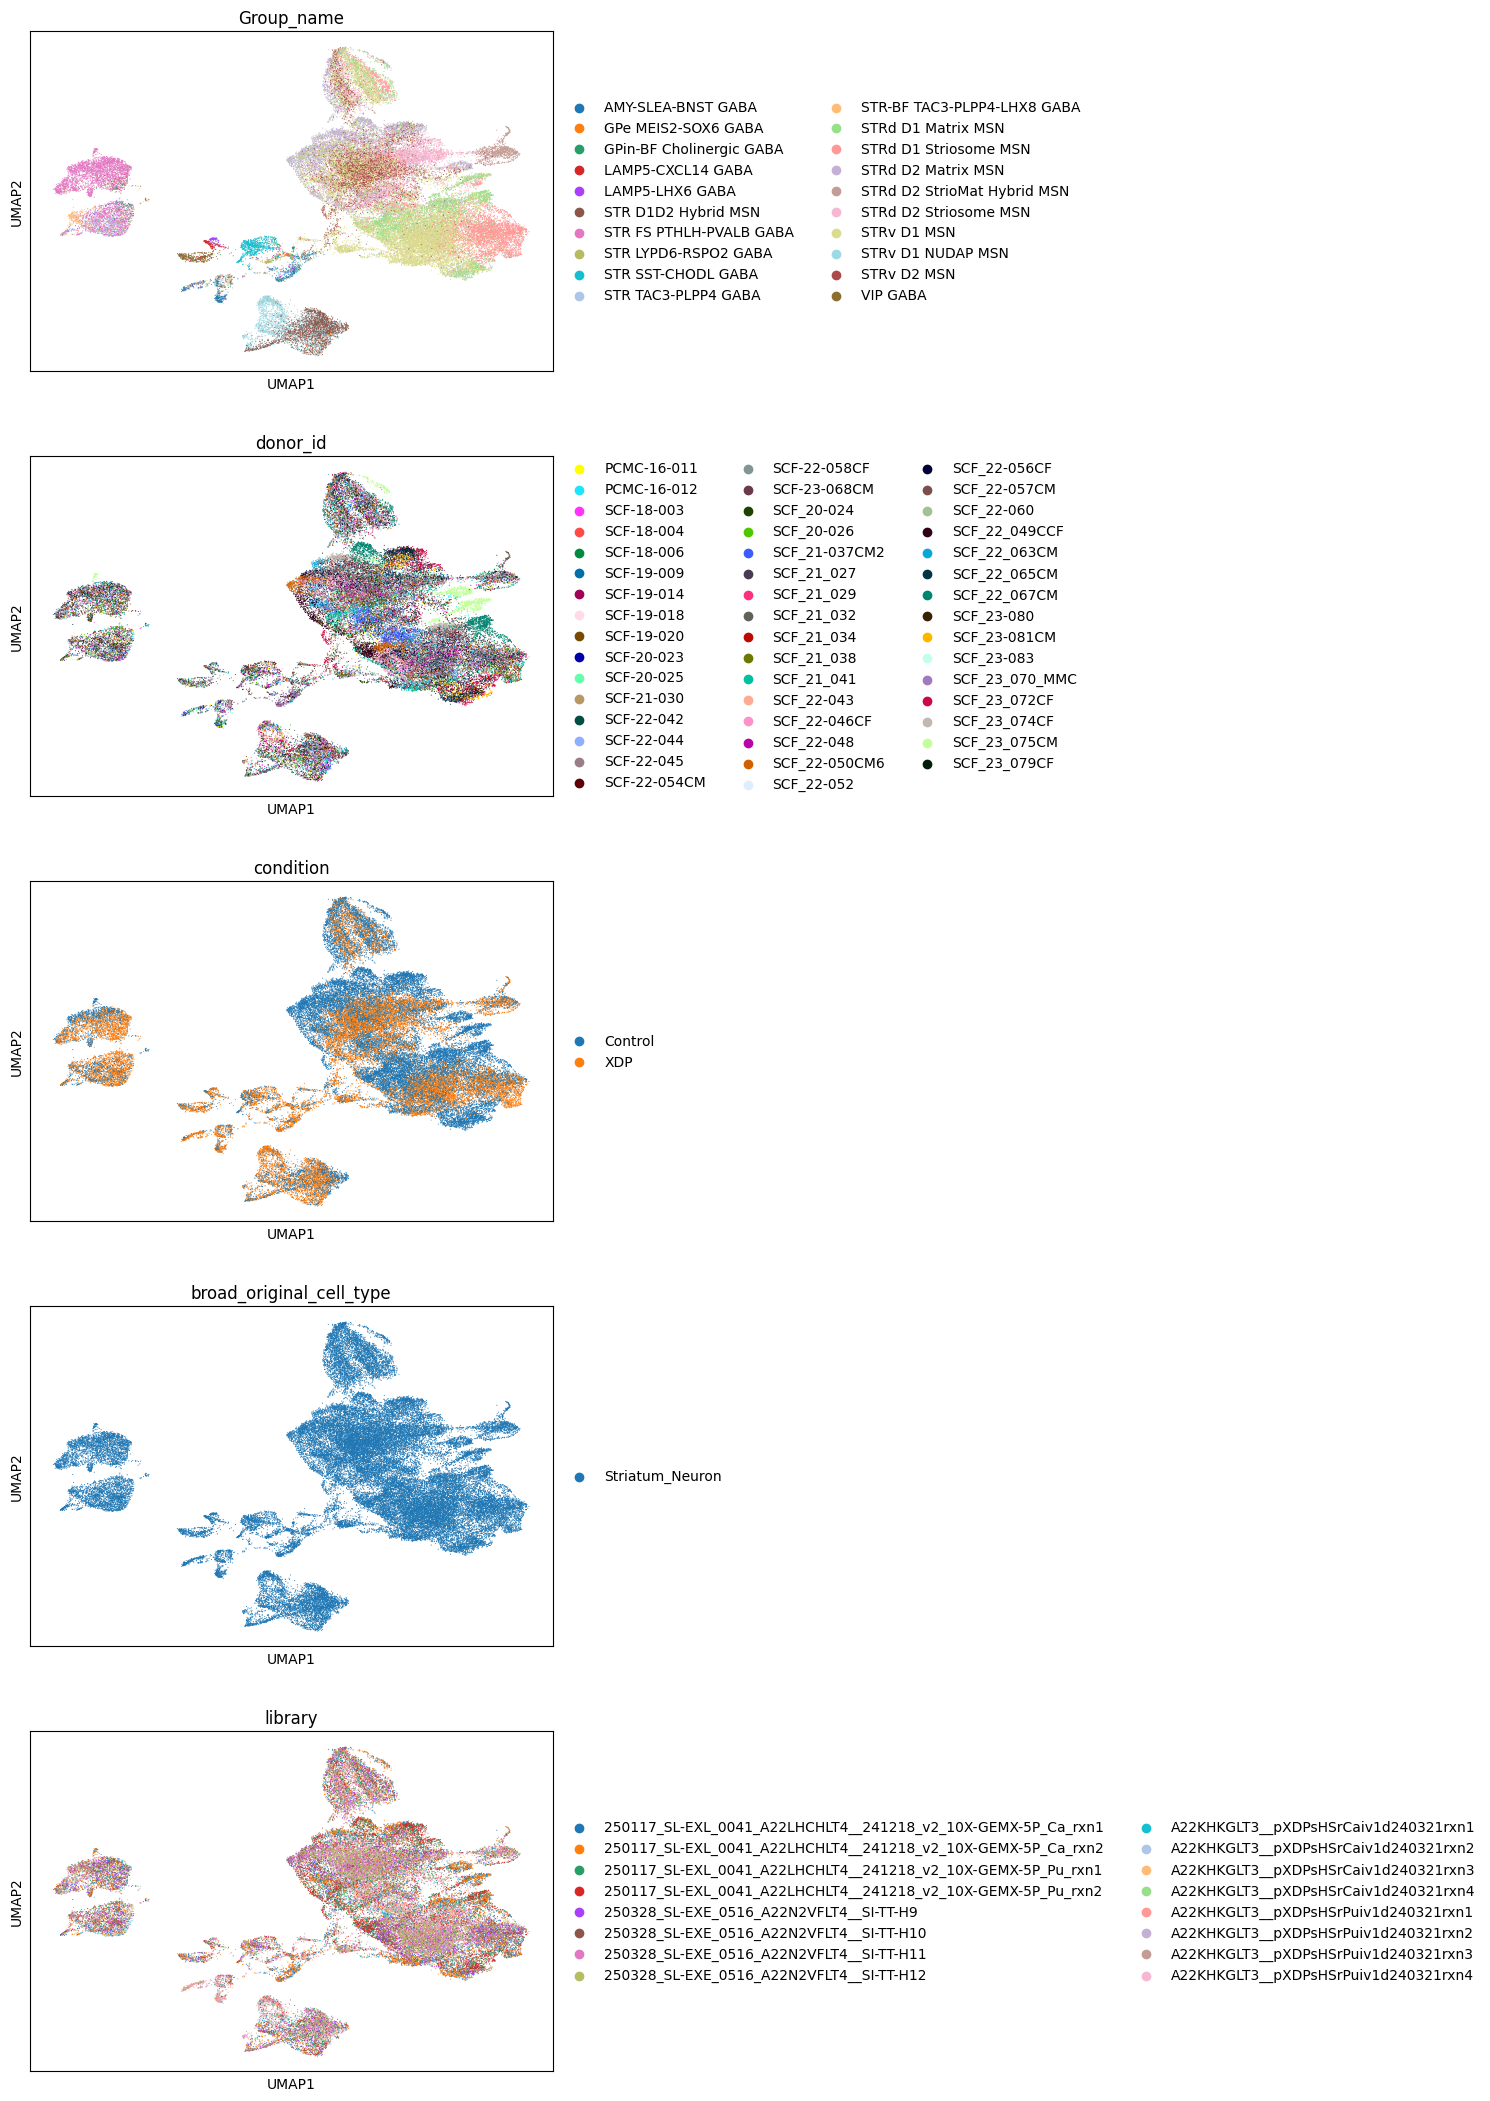

In [3]:
var_tp_plot = ["Group_name", SAMPLE_VARIABLE, CONTRAST_VARIABLE, "broad_original_cell_type", "library"]
sc.pl.umap(adata, color=var_tp_plot, ncols=1)

# MrVI initialisation and training

In [4]:
# Filter hvg
adata = adata[:, adata.var["highly_variable"]].copy()

/tmp/ipykernel_792380/3469463330.py:2: UserWarning: MRVI model is being setup with PyTorch backend
  MRVI.setup_anndata(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


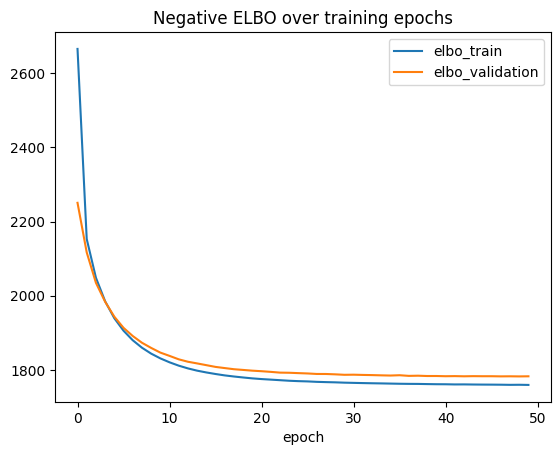

In [5]:
# Initialise
MRVI.setup_anndata(
        adata, 
        layer="counts",
        sample_key=TARGET_COV, 
        batch_key=NUISANCE_COV,
        backend="torch",
        #labels_key  = "cell_type", #activates the MoG prior guided by labels, → the paper calls this "CT prior"
        # categorical_covariate_keys=None,  # Additional covariates
        # continuous_covariate_keys=None    # Continuous covariates
) 

# Train
model = MRVI(
        adata,    
        backend = "torch",     
        # n_latent   = 10,
        # n_latent_u = 10,
        # u_prior_mixture_k = 20, # maye set to the numebr foc ct
)

model.train(
        max_epochs=N_EPOCHS, 
        batch_size=BATCH,
        early_stopping=True,
        datasplitter_kwargs={'num_workers': 16},
        #  plan_kwargs = {"lr": 1e-3},
)

# Plot loss
fig, ax = plt.subplots(1, 1)
model.history["elbo_train"].plot(ax=ax, label="train")
model.history["elbo_validation"].plot(ax=ax, label="validation")
ax.set(title="Negative ELBO over training epochs")
ax.legend()

# Save / reload (optional)
# model.save(f"{SAVE_FOLDER}/mrvi_model", overwrite=True)
# model = scvi.model.MRVI.load(f"{SAVE_FOLDER}/mrvi_model", adata=adata)


# Visualise u and z space

In [6]:
adata.obsm["X_mrvi_u"] = model.get_latent_representation(give_z=False)  # u space
adata.obsm["X_mrvi_z"] = model.get_latent_representation(give_z=True)   # z space

# Visualise u (should show cell types, NOT donor separation)
sc.pp.neighbors(adata, use_rep="X_mrvi_u")
sc.tl.umap(adata, key_added="umap_u")

# Visualise z (should show donor/condition separation WITHIN cell types)
sc.pp.neighbors(adata, use_rep="X_mrvi_z")
sc.tl.umap(adata, key_added="umap_z")


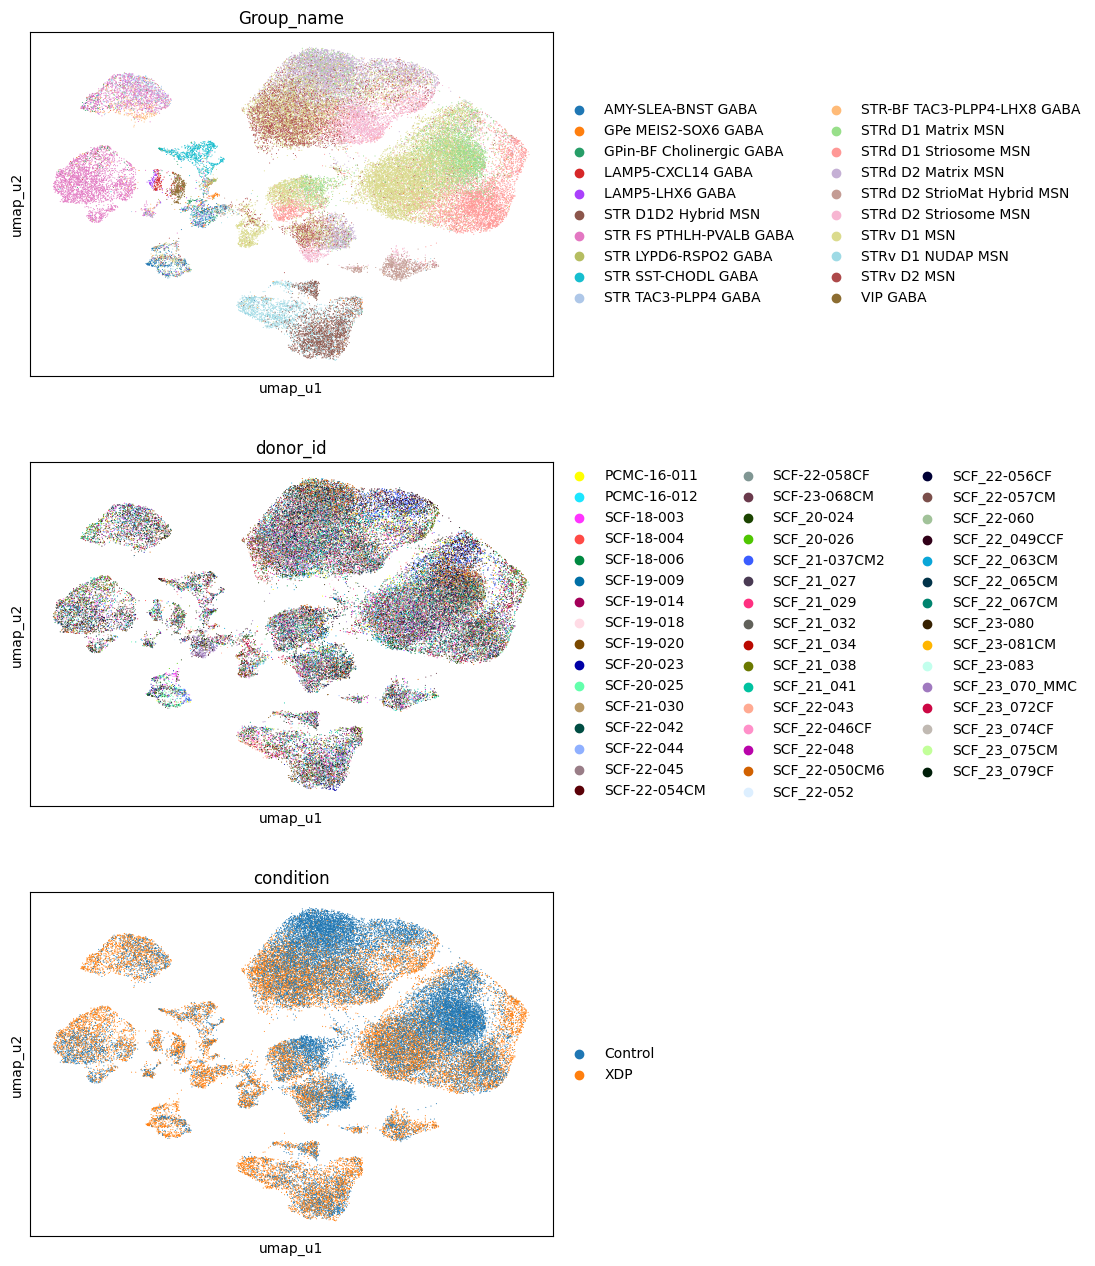

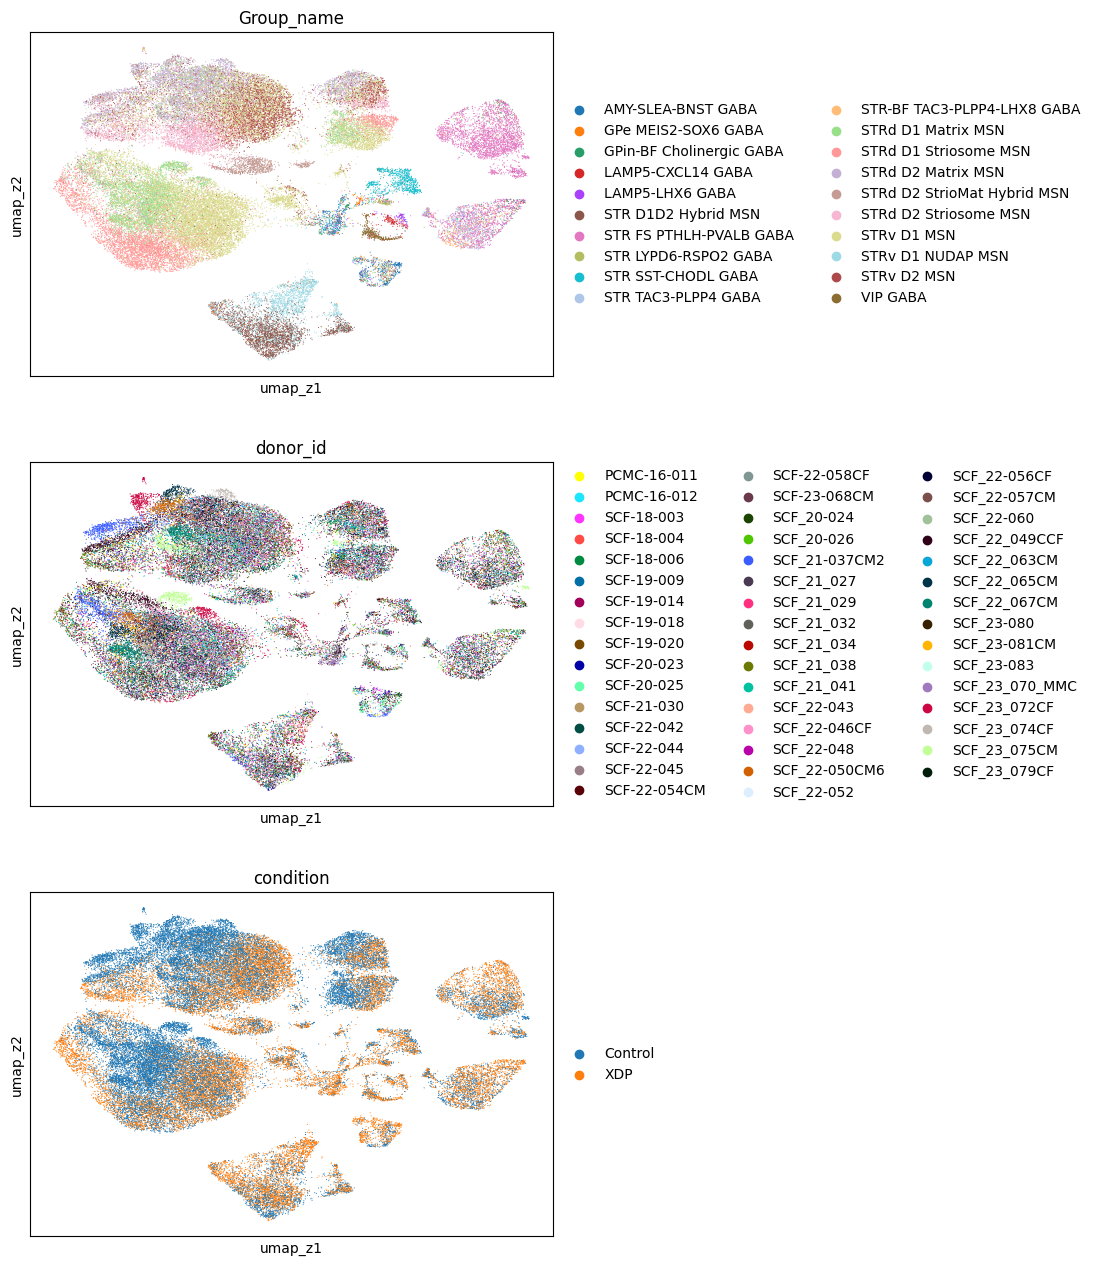

In [7]:
var_tp_plot = ["Group_name", SAMPLE_VARIABLE, CONTRAST_VARIABLE]
sc.pl.embedding(adata, basis="umap_u", color=var_tp_plot, ncols=1)
sc.pl.embedding(adata, basis="umap_z", color=var_tp_plot, ncols=1)

# Save

In [14]:
# save temp

# Save / reload (optional)
save_dir = "/home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model"
model.save(
    save_dir,
    overwrite=True,
    save_anndata=True,  # Critical: saves adata.h5ad
    legacy_mudata_format=False,
)
adata.write_h5ad(f"/home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model/nucseq_mrvi.h5ad")

In [5]:
import scvi

In [10]:
adata = sc.read_h5ad(f"/home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model/nucseq_mrvi.h5ad")
scvi.external.MRVI.backend = "torch"
model = scvi.external.MRVI.load(f"/home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model")


INFO     File /home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model/model.pt already downloaded                        


/tmp/ipykernel_803679/1658278811.py:3: UserWarning: MRVI model is being loaded with PyTorch backend
  model = scvi.external.MRVI.load(f"/home/gdallagl/myworkdir/XDP/data/_tmp/mrvi_model")


# Cluster D(n) - counterfactual disatnces

# generate aggregate data

In [10]:
sample_meta = (
    adata.obs.groupby(SAMPLE_VARIABLE, as_index=False)
      .agg(lambda x: x.mean() if x.dtype.kind in "biufc" else x.iloc[0])
)
sample_meta.head(5)

/tmp/ipykernel_792380/1738951390.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(SAMPLE_VARIABLE, as_index=False)


,donor_id,background_fraction,cell_probability,cell_size,droplet_efficiency,barcode,bcl,rna_index,library,library__barcode,...,dv200,ph,mqs_numerical,mqs,immediate.cause.of.death,infection_related_death,_indices,_scvi_sample,_scvi_batch,_scvi_labels
0,PCMC-16-011,0.063968,0.999939,9011.204141,1.447443,TTTGGTTCAGCCTTTC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TTTGGTTC...,...,0.79,6.0,1.0,E Redo,Dystonia,No,10133.587074,0.0,12.567325,0.0
1,PCMC-16-012,0.010796,0.999952,12135.480045,1.919568,GTACTTTTCATGCAAC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTACTTTT...,...,0.70,6.4,5.0,A,Dystonia,No,12666.213573,1.0,11.411178,0.0
2,SCF-18-003,0.011082,0.999952,14177.385332,2.086808,CATATTCTCTGACCTC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CATATTCT...,...,0.79,6.4,5.0,A,"Pnuemonia, Dystonia",Yes,9467.563392,2.0,12.426532,0.0
3,SCF-18-004,0.026918,0.999949,12869.463464,1.882253,CACATTTGTTGATTGC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CACATTTG...,...,0.78,6.0,4.5,AB,Pnuemonia,Yes,11869.236364,3.0,11.560606,0.0
4,SCF-18-006,0.013863,0.999951,14038.638059,2.076031,GGAACTTCAAGTCTAC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGAACTTC...,...,0.76,6.2,5.0,A,Dystonia,No,10602.347734,4.0,12.036881,0.0


### Groupby Unsupervised laiden

In [11]:
# (n_cells, n_samples, n_samples) --> one D(n) for each cell
sample_distances = model.get_local_sample_distances(
    adata,
    keep_cell    = True,    # keep per-cell distances (needed for clustering)
    batch_size   = 128,
)

sample_distances

  0%|          | 0/421 [00:00<?, ?it/s]

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scvi/external/mrvi_torch/_model.py:426: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cf_sample=torch.Tensor(cf_sample),
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/torch/nn/functional.py:6629: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:80.)
  attn_output = scaled_dot_produ

<xarray.Dataset> Size: 476MB
Dimensions:    (cell_name: 53864, sample_x: 47, sample_y: 47)
Coordinates:
  * cell_name  (cell_name) object 431kB 'A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4...
  * sample_x   (sample_x) object 376B 'PCMC-16-011' ... 'SCF_23_079CF'
  * sample_y   (sample_y) object 376B 'PCMC-16-011' ... 'SCF_23_079CF'
Data variables:
    cell       (cell_name, sample_x, sample_y) float32 476MB 0.0 0.7601 ... 0.0

Flattened shape: (53864, 2209)
PCA shape: (53864, 20)
Explained variance ratio (first 5 PCs): [0.8080186  0.04030121 0.0396855  0.02382457 0.01724105]

Found 9 cell proximity clusters
mrvi_cell_proximity_cluster
2    20031
4     7589
5     7271
6     5501
1     4598
0     3004
7     2771
8     2261
3      838
Name: count, dtype: int64


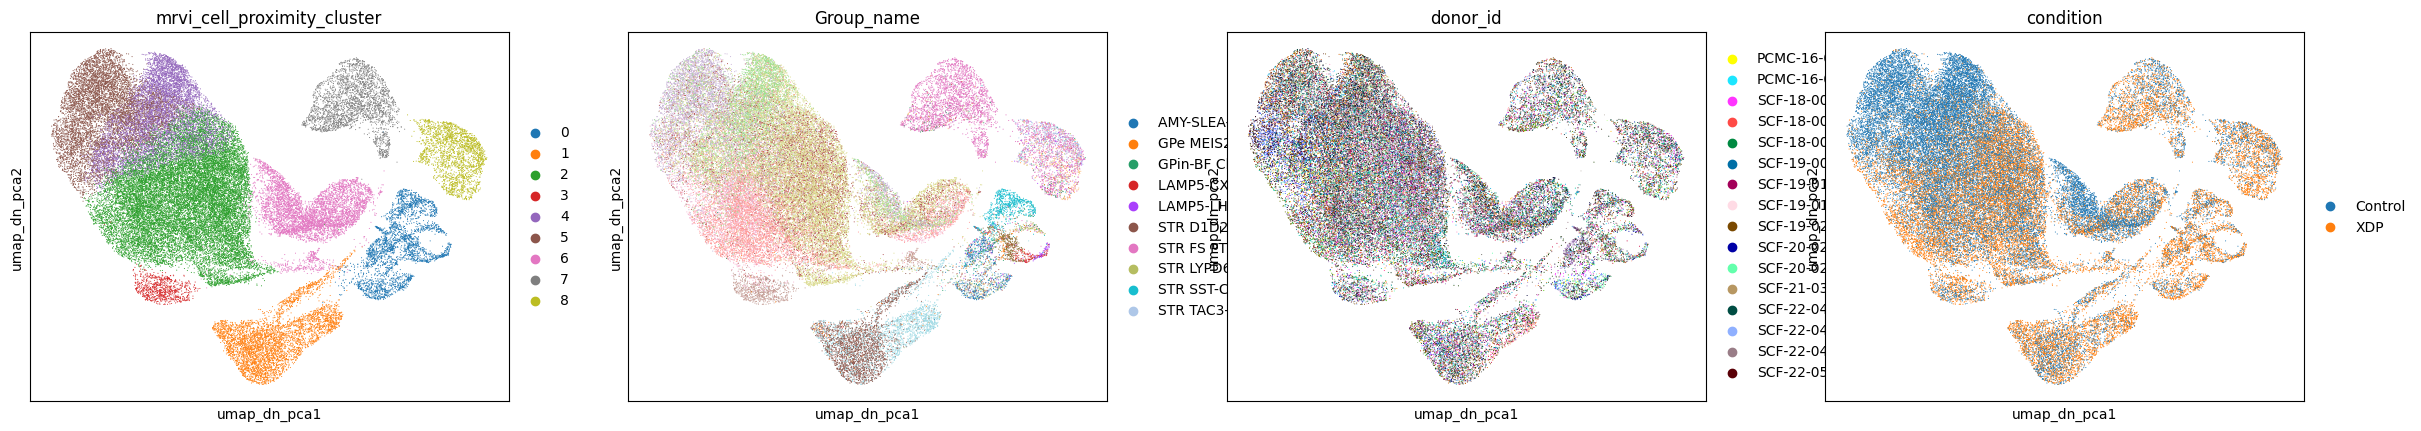

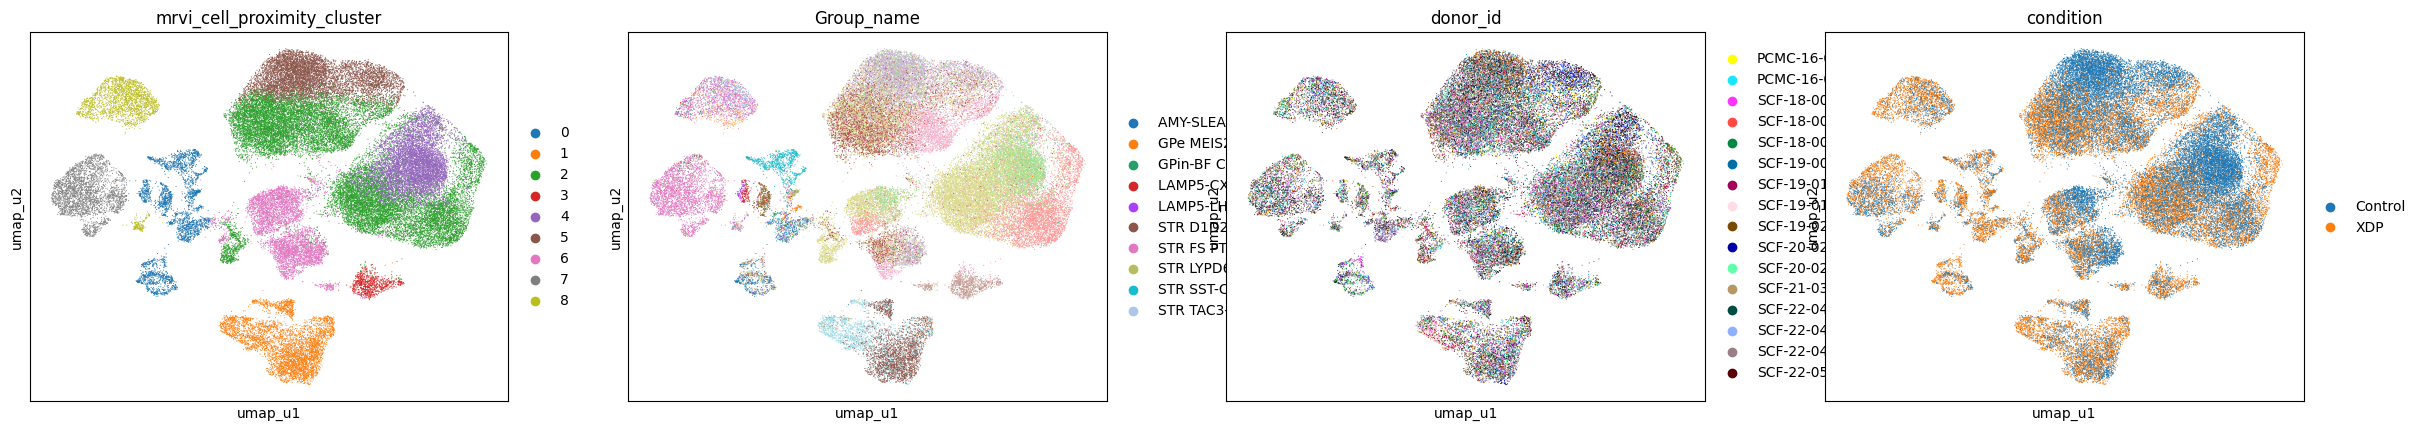

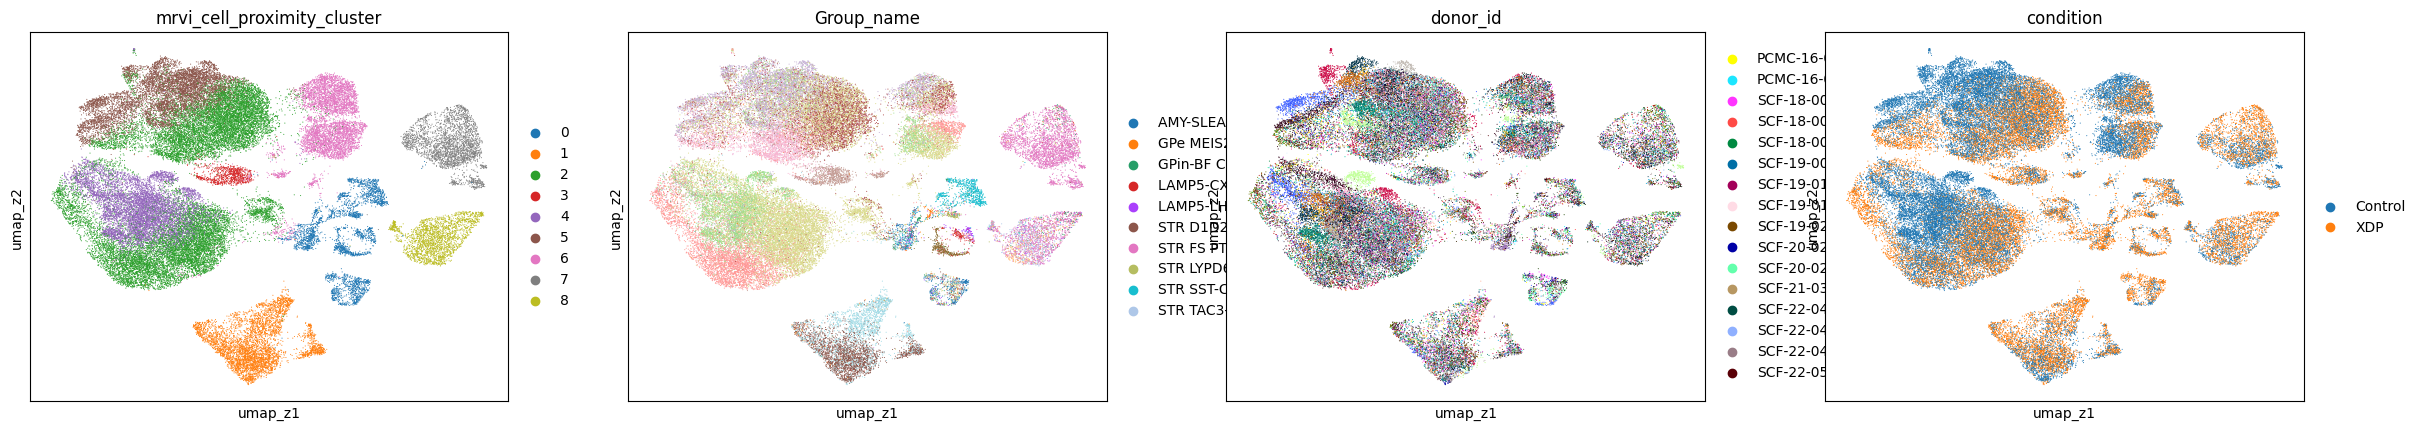

In [12]:
from sklearn.decomposition import PCA

# Flatten each distance matrix into a vector (S^2)
D = sample_distances["cell"].values  # shape: (n_cells, n_samples, n_samples)
n_cells = D.shape[0]
n_samples = D.shape[1]
D_flat = D.reshape(n_cells, -1)
print(f"Flattened shape: {D_flat.shape}")

# 2b. PCA for dimensionality reduction (distance matrices are high-dim and redundant)
pca = PCA(n_components=20)  # or use scree plot to choose
D_pca = pca.fit_transform(D_flat)
print(f"PCA shape: {D_pca.shape}")
print(f"Explained variance ratio (first 5 PCs): {pca.explained_variance_ratio_[:5]}")

# Store in adata for visualization
adata.obsm["X_sample_distance_pca"] = D_pca

# 2c. Cluster using Leiden (scanpy workflow) or KMeans
# Option A: Leiden (recommended - as in the paper)
sc.pp.neighbors(adata, use_rep="X_sample_distance_pca", n_neighbors=15)
sc.tl.umap(adata, key_added="umap_dn_pca")
sc.tl.leiden(adata, resolution=0.1, key_added="mrvi_cell_proximity_cluster", flavor="igraph", n_iterations=2)

print(f"\nFound {adata.obs['mrvi_cell_proximity_cluster'].nunique()} cell proximity clusters")
print(adata.obs["mrvi_cell_proximity_cluster"].value_counts())

sc.pl.embedding(adata, basis="umap_dn_pca", color=["mrvi_cell_proximity_cluster", *var_tp_plot])
sc.pl.embedding(adata, basis="umap_u", color=["mrvi_cell_proximity_cluster", *var_tp_plot])
sc.pl.embedding(adata, basis="umap_z", color=["mrvi_cell_proximity_cluster", *var_tp_plot])


In [13]:
ffff

NameError: name 'ffff' is not defined

In [ ]:
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering
from scipy.spatial.distance import squareform

import matplotlib.colors as mcolors
import matplotlib.cm as mcm

def make_col_colors(sample_meta, categorical_cols, numeric_cols):
    meta = sample_meta.copy()
    if isinstance(meta.index, pd.MultiIndex):
        meta.index = meta.index.get_level_values(0)
    meta.index = meta.index.astype(str)

    col_colors = {}

    # ── Categorical: discrete tab10 palette ──────────────────────────────────
    for col in categorical_cols:
        if col not in meta.columns:
            continue
        series = meta[col].astype(str)
        unique_vals = series.unique()
        palette = dict(zip(unique_vals, sns.color_palette("tab10", len(unique_vals))))
        col_colors[col] = series.map(palette)

    # ── Numeric: continuous gradient (viridis by default) ────────────────────
    for col in numeric_cols:
        if col not in meta.columns:
            continue
        series = meta[col].astype(float)
        vmin, vmax = series.min(), series.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = mcm.get_cmap("viridis")
        # Map each value to an RGBA tuple
        col_colors[col] = series.map(lambda v: cmap(norm(v)))

    return pd.DataFrame(col_colors)

def plot_clustermap(D_cluster_df, sample_meta, var_to_plot_in_clustermap, figsize=(10, 10), cmap="Reds"):

    col_colors = make_col_colors(sample_meta, var_to_plot_in_clustermap)

    dists = D_cluster_df.values
    ds = squareform(dists)           # condense square → 1D
    Z = linkage(ds, method="ward")   # build tree
    Z = optimal_leaf_ordering(Z, ds) # reorder leaves for visual clarity

    sns.clustermap(
        D_cluster_df,
        row_linkage=Z,
        col_linkage=Z,        # symmetric matrix → same for both axes
        cmap=cmap,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        col_colors=col_colors,
        row_colors=col_colors,
    )
    plt.show()

# Usage
for c in  adata.obs["mrvi_cell_proximity_cluster"].unique():

    # ── Choose a cell cluster to analyze (e.g., cluster with strongest effect) ──
    cluster_of_interest = c
    mask = adata.obs["mrvi_cell_proximity_cluster"] == cluster_of_interest
    cell_names_in_cluster = adata.obs_names[mask].tolist() # sleect cells of this cluster

    # slecte cells of this cluster and averge theu D
    D_cluster = (
        sample_distances["cell"] 
        .sel(cell_name=cell_names_in_cluster)  # ← select along the cell dimension
        .mean(dim="cell_name")                  # ← average over cells
    )
    # Make dataframe
    D_cluster_df = pd.DataFrame(D_cluster.values, index=D_cluster["sample_x"].values, columns=D_cluster["sample_y"].values)

    #### make metaadta

    # Categorize columns by type
    categorical_cols = [CONTRAST_VARIABLE, "sex", "cohort", "infection_related_death", "immediate.cause.of.death"]
    numeric_cols = ["disease_duration", "age_of_death", "repeat_length"]
    var_to_plot_in_clustermap = [*categorical_cols, *numeric_cols]

    def get_mode(series):
        """Return most common value, or first if tie."""
        mode_vals = series.mode()
        return mode_vals[0] if len(mode_vals) > 0 else series.iloc[0]

    # Build agg dict with proper function references
    agg_dict = {}
    for col in categorical_cols:
        if col in adata.obs.columns:
            agg_dict[col] = get_mode  # function reference, not lambda

    for col in numeric_cols:
        if col in adata.obs.columns:
            agg_dict[col] = 'median'

    # Now aggregate
    sample_meta = (
        adata.obs[[SAMPLE_VARIABLE, *var_to_plot_in_clustermap]]
        .groupby(SAMPLE_VARIABLE)
        .agg(agg_dict)
    )

    plot_clustermap(D_cluster_df, sample_meta, var_to_plot_in_clustermap)

In [ ]:
# Check the actual dtypes
print("Column dtypes:")
for col in ["disease_duration", "age_of_onset", "age_of_death", "repeat_length"]:
    if col in adata.obs.columns:
        print(f"  {col}: {adata.obs[col].dtype}")

Column dtypes:
  disease_duration: float64
  age_of_onset: category
  age_of_death: float64
  repeat_length: float64


### Groupby specific Cov

In [ ]:
# (n_cells, n_samples, n_samples) --> one D(n) for each cell
dists = model.get_local_sample_distances(
    adata,
    groupby="Group_name",
    batch_size   = 128,
)

dists

In [ ]:
# Loop over cell type annotations (Group_name)
for group_idx, group_name in enumerate(dists.coords["Group_name_name"].values):
    print(f"\nProcessing Group: {group_name}")
    
    # Extract pre-averaged distance matrix for this group
    # Note: use .isel() for integer indexing or .sel() for label-based indexing
    D_cluster = dists["Group_name"].isel(Group_name_name=group_idx)
    
    D_cluster_df = pd.DataFrame(
        D_cluster.values,
        index=D_cluster["sample_x"].values,
        columns=D_cluster["sample_y"].values
    )
    
    # Count cells in this group
    n_cells = (adata.obs["Group_name"] == group_name).sum()
    
    plot_clustermap(
        D_cluster_df, 
        sample_meta, 
        var_to_plot_in_clustermap,
    )

# DEG

In [11]:
# Filters samples: Identifies which samples belong to group1 vs group2
# Fits linear model: For each cell, regresses z counterfactuals against a binary covariate [1 if diseased, 0 if healthy]
# Decodes: Computes h^diseased and h^healthy for each cell
# Returns LFCs: Outputs log2(fold change) for every gene in every cell

# order to have ehalthy as baseline
model.sample_info[CONTRAST_VARIABLE] = model.sample_info[CONTRAST_VARIABLE].cat.reorder_categories([CONTRAST_BASELINE, CONTRAST_STIM])

# Run DEG
    # # Results are stored in:
    # adata.varm['var_1']
    #store_lfc=True   # Store LFCs in adata.varm['delta_<covariate>']
sample_cov_keys = [CONTRAST_VARIABLE, "sex"]
de_res = model.differential_expression(
    sample_cov_keys=sample_cov_keys, 
    store_lfc=True, #a matrix of size (n_cells × n_genes × n_covariates)
    store_lfc_metadata_subset=[CONTRAST_VARIABLE], #compute LFCs for a subset of covariates
    use_vmap=False, #for jax
    batch_size=128, 
    normalize_design_matrix=True,  #norm cont 
    add_batch_specific_offsets=False,
    filter_inadmissible_samples=True, # Filter out out-of-distribution samples before regression --> When some samples are missing entire cell types
    lambd=0 #lambda in L1 regulrization on leianr mdole
    #delta # de_res['pde']: Posterior DE probability for each gene --< pde = 0.95 → 95% probability gene is upregulated by at least δ
)

  0%|          | 0/421 [00:00<?, ?it/s]/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scvi/external/mrvi_torch/_model.py:1462: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cf_sample=torch.Tensor(cf_sample),
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/torch/nn/functional.py:6629: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.c

KeyboardInterrupt: 

In [12]:
import jax
print(jax.devices())

[CpuDevice(id=0)]


In [19]:
# First, diagnose the problem
print("="*60)
print("DATA SIZE DIAGNOSTIC")
print("="*60)
print(f"Total cells in adata: {adata.n_obs:,}")
print(f"Total genes: {adata.n_vars:,}")
print()

# Estimate memory needed
n_cells = adata.n_obs
n_genes = adata.n_vars
n_covariates = 1  # After store_lfc_metadata_subset

memory_gb = (n_cells * n_genes * n_covariates * 4) / (1024**3)
print(f"Estimated RAM for LFCs: {memory_gb:.2f} GB")
print(f"  (this is ONLY the LFC matrix, actual usage is 2-3x higher)")
print()

if memory_gb > 10:
    print("⚠️  WARNING: This will likely cause RAM overflow!")
    print("→  You MUST subset your data")
print("="*60)

DATA SIZE DIAGNOSTIC
Total cells in adata: 53,864
Total genes: 3,000

Estimated RAM for LFCs: 0.60 GB
  (this is ONLY the LFC matrix, actual usage is 2-3x higher)



In [ ]:
# Output Dataset Structure
# ========================
# beta (n_cells, n_latent, n_covariates)
#   - Regression coefficients in latent space
#
# effect_size (n_cells, n_covariates)
#   - ||beta||_2^2 - overall effect magnitude
#
# pvalue (n_cells, n_covariates)
#   - P-values from t-test
#
# padj (n_cells, n_covariates)
#   - FDR-corrected p-values (Benjamini-Hochberg)
#
# lfc (n_cells, n_genes, n_covariates)
#   - Gene-level log fold changes (if store_lfc=True)
#
# lfc_std (n_cells, n_genes, n_covariates)
#   - Standard deviation of LFC (if delta not None)
#
# pde (n_cells, n_genes, n_covariates)
#   - Posterior DE probability (if delta not None)
#
# baseline_expression (n_cells, n_genes)
#   - Baseline gene expression (if store_baseline=True)
#
# n_samples (n_cells,)
#   - Number of admissible samples (if filtering enabled)

In [ ]:
 de_res['effect_size'].sel(covariate=f"{CONTRAST_VARIABLE}_{CONSTRAST_STIM}").values

In [ ]:
# plot effect size (beta disease) on umap
adata.obs["Covid_DE_eff_size"] = de_res.effect_size.sel(covariate="Status_Covid").values
adata.obs['disease_effect'] = de_res['effect_size'].sel(covariate="Status_Covid").values

sc.pl.umap(
    adata,
    color=["initial_clustering", "Covid_DE_eff_size"],
    frameon=False,
    ncols=1,
    vmax=np.quantile(de_res.effect_size.values, 0.95),
    cmap="viridis",
)

In [ ]:
# Access LFCs:
lfc = de_res['lfc']

adata.obs['disease_effect'] = de_res['effect_size'].values[:, 0]


In [ ]:
# Example: Find cells significantly affected by disease
de_res = model.differential_expression(
    sample_cov_keys=['disease', 'sex'],
    filter_inadmissible_samples=True,
)

# Get adjusted p-values for 'disease' (first covariate, index 0)
padj_disease = de_res['padj'].values[:, 0]  # Shape: (n_cells,)

# Find significantly affected cells (FDR < 0.05)
sig_cells = padj_disease < 0.05
adata.obs['disease_significant'] = sig_cells

# How many cells are affected?
print(f"{sig_cells.sum()} / {len(sig_cells)} cells significantly affected")

# Which cell types are enriched?
adata.obs.groupby('cell_type')['disease_significant'].mean().sort_values()

# Combine with effect size for biological significance
effect_size = de_res['effect_size'].values[:, 0]
strong_effect = (padj_disease < 0.05) & (effect_size > 100)

print(f"{strong_effect.sum()} cells with strong + significant effect")